# 06 - Phase 1: Pretrained CNN + BiLSTM Baseline Models
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Establish a rigorous, controlled baseline benchmarking three pretrained CNN backbones with a shared Bidirectional LSTM sequence classifier on the speaker-independent Tai Phake digit dataset:
1. **MobileNetV2 + BiLSTM**
2. **EfficientNetB0 + BiLSTM**
3. **ResNet50 + BiLSTM**

---

### Experimental Controls & Protocol:
- **Dataset**: Existing cropped lips dataset (`data/cropped_lips_dataset`), 30 speakers, 11 digits (`d0`–`d10`), 330 utterances, 13,610 frames.
- **Crop Geometry**: $96\times 96$ RGB, pixel normalization to $[0, 1]$ (`img / 255.0`). No recropping or image regeneration.
- **Data Augmentation**: **OFF** (strictly controlled baseline).
- **Speaker-Independent Split**: Fixed random seed `42`:
  - **20 Train Speakers** (220 utterances)
  - **4 Validation Speakers** (44 utterances)
  - **6 Unseen Test Speakers** (66 utterances, strictly held-out until final model evaluation)
  - Zero speaker overlap across splits; saved to `results/pretrained_phase1/speaker_split.json`.
- **Temporal Processing**: Exactly 30 frames per utterance. Deterministic uniform sampling for $>30$ frames; deterministic interpolation/repetition for $<30$ frames.
- **Architecture**:
  - ImageNet pretrained CNN backbones initially frozen (`trainable = False`).
  - Global Average Pooling $\to$ feature vector ($D=1280$ for MobileNetV2/EfficientNetB0, $D=2048$ for ResNet50).
  - Across 30 frames $	o$ Shared BiLSTM head: `Bidirectional(LSTM(64))` $\to$ `Dropout(0.3)` $\to$ `Dense(11, activation='softmax')`.
- **Training**: Adam ($10^{-4}$), Sparse Categorical Crossentropy, batch size 16, max 50 epochs, Early Stopping (`patience=15`, restoring best validation weights).
- **Results Directory**: `results/pretrained_phase1/`

## 1. Imports, Environment Verification & Random Seed
We configure fixed seeds across Python `random`, `numpy`, and `tensorflow` for strict reproducibility.

In [12]:
# Section 1: Environment & Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from PIL import Image

import tensorflow as tf
import keras

# Reproducibility Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

# Dataset directories: easily switchable by pointing or replacing data/processed/train, val, test
DATA_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

RESULTS_DIR = PROJECT_ROOT / "results" / "pretrained_phase1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# # Hyperparameters & Constants
# NUM_CLASSES = 11
# NUM_FRAMES = 30
# FRAME_WIDTH = 96
# FRAME_HEIGHT = 96
# FRAME_CHANNELS = 3
# BATCH_SIZE = 16
# MAX_EPOCHS = 40
# LEARNING_RATE = 1e-4
# PATIENCE = 8
# RNN_UNITS = 128
# DROPOUT_RATE = 0.3

# Hyperparameters new
NUM_CLASSES = 11
NUM_FRAMES = 30

FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3

BATCH_SIZE = 16

RNN_UNITS = 128
DROPOUT_RATE = 0.3

# Stage 1: frozen pretrained CNN
STAGE1_LR = 1e-4
STAGE1_MAX_EPOCHS = 40
STAGE1_PATIENCE = 8

# Stage 2: fine-tuning
STAGE2_LR = 1e-5
STAGE2_MAX_EPOCHS = 25
STAGE2_PATIENCE = 6

FINE_TUNE_FRACTION = 0.20

DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
print(f"Seed:               {SEED}")
print(f"Project Root:       {PROJECT_ROOT}")
print(f"Train Directory:    {TRAIN_DIR}")
print(f"Val Directory:      {VAL_DIR}")
print(f"Test Directory:     {TEST_DIR}")
print(f"Results Directory:  {RESULTS_DIR}")


TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Seed:               42
Project Root:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Train Directory:    /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/train
Val Directory:      /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/val
Test Directory:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/processed/test
Results Directory:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1


## 2. Speaker-Independent Dataset Partitioning
We partition the 30 speakers into:
- **20 Training Speakers** (for training the recurrent classifier)
- **4 Validation Speakers** (for EarlyStopping and model checkpoint selection)
- **6 Unseen Test Speakers** (strictly isolated for final generalizability assessment)

All utterances for any given speaker remain strictly within their assigned partition.

In [13]:
# Section 2: Canonical Speaker-Independent Split Discovery
train_speakers = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
val_speakers = sorted([d.name for d in VAL_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
test_speakers = sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
all_speakers = sorted(train_speakers + val_speakers + test_speakers)

print(f"Total Speakers Discovered ({len(all_speakers)})")
print(f"Train Speakers ({len(train_speakers)}): {train_speakers[:10]}... (total {len(train_speakers)})")
print(f"Validation Speakers ({len(val_speakers)}): {val_speakers}")
print(f"Unseen Test Speakers ({len(test_speakers)}): {test_speakers}")

# Strict verification of mutual exclusivity and completeness
assert len(set(train_speakers) & set(val_speakers)) == 0, "Train-Val overlap detected!"
assert len(set(train_speakers) & set(test_speakers)) == 0, "Train-Test overlap detected!"
assert len(set(val_speakers) & set(test_speakers)) == 0, "Val-Test overlap detected!"

# Verify that test and val speakers do not contain augmented variants
for s in test_speakers:
    assert "_aug" not in s, f"Leaked augmented speaker {s} found in test partition!"
for s in val_speakers:
    assert "_aug" not in s, f"Leaked augmented speaker {s} found in val partition!"

# Persist partition specification
speaker_split_data = {
    "random_seed": SEED,
    "num_train_speakers": len(train_speakers),
    "num_val_speakers": len(val_speakers),
    "num_test_speakers": len(test_speakers),
    "train_speakers": train_speakers,
    "val_speakers": val_speakers,
    "test_speakers": test_speakers
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(speaker_split_data, f, indent=2)

print(f"Saved canonical speaker partition metadata to: {RESULTS_DIR / 'speaker_split.json'}")


Total Speakers Discovered (110)
Train Speakers (100): ['s1', 's11', 's11_aug1', 's11_aug2', 's11_aug3', 's11_aug4', 's13', 's13_aug1', 's13_aug2', 's13_aug3']... (total 100)
Validation Speakers (4): ['s12', 's19', 's21', 's29']
Unseen Test Speakers (6): ['s10', 's16', 's18', 's24', 's28', 's9']
Saved canonical speaker partition metadata to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/speaker_split.json


## 3. Utterance Manifest & Deterministic 30-Frame Temporal Preprocessing
Every utterance sequence is standardized to exactly $T=30$ frames:
- If raw frame count $=30$: all 30 frames are preserved.
- If raw frame count $>30$: 30 frames are uniformly sampled across the temporal span using `np.linspace`.
- If raw frame count $<30$: frames are deterministically interpolated/repeated via rounding `np.linspace` indices.

In [14]:
# Section 3: Manifest Indexing & Temporal Standardization
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

def sample_or_interpolate_frames(fpaths, target=NUM_FRAMES):
    n = len(fpaths)
    if n == target:
        indices = list(range(target))
    else:
        indices = np.round(np.linspace(0, n - 1, target)).astype(int)
    return [str(fpaths[i]) for i in indices]

utterances = []
split_dirs = {"train": TRAIN_DIR, "val": VAL_DIR, "test": TEST_DIR}

for split_name, s_dir in split_dirs.items():
    speakers = sorted([d.name for d in s_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    for spk in speakers:
        for digit in DIGIT_CLASSES:
            digit_dir = s_dir / spk / digit
            if not digit_dir.exists():
                continue
            frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
            if len(frames) == 0:
                continue
            sampled_frames = sample_or_interpolate_frames(frames, NUM_FRAMES)
            utterances.append({
                "speaker": spk,
                "digit": digit,
                "digit_id": CLASS_TO_ID[digit],
                "split": split_name,
                "raw_frame_count": len(frames),
                "sampled_frame_paths": sampled_frames
            })

df_manifest = pd.DataFrame(utterances)
print(f"Total Utterances Indexed: {len(df_manifest)}")
print(f"  Training Split:   {len(df_manifest[df_manifest['split']=='train'])} utterances ({len(train_speakers)} speakers)")
print(f"  Validation Split: {len(df_manifest[df_manifest['split']=='val'])} utterances ({len(val_speakers)} speakers)")
print(f"  Test Split:       {len(df_manifest[df_manifest['split']=='test'])} utterances ({len(test_speakers)} speakers)")

df_manifest[["speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    RESULTS_DIR / "utterance_manifest.csv", index=False
)
print(f"Saved utterance manifest to: {RESULTS_DIR / 'utterance_manifest.csv'}")

# Frame count distribution summary
raw_counts = df_manifest['raw_frame_count']
print(f"\nRaw Frame Counts: Min={raw_counts.min()}, Max={raw_counts.max()}, Median={raw_counts.median():.0f}, Mean={raw_counts.mean():.1f}")
df_manifest.groupby("split")["raw_frame_count"].describe()


Total Utterances Indexed: 1210
  Training Split:   1100 utterances (100 speakers)
  Validation Split: 44 utterances (4 speakers)
  Test Split:       66 utterances (6 speakers)
Saved utterance manifest to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/utterance_manifest.csv

Raw Frame Counts: Min=15, Max=92, Median=39, Mean=39.8


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,66.0,43.909091,10.728434,21.0,35.0,44.5,51.00,68.0
train,1100.0,39.209091,10.619651,15.0,32.0,38.0,44.00,92.0
val,44.0,47.409091,16.704432,27.0,34.0,43.5,56.25,90.0


## 4. In-Memory Sequence Loading & Normalization
We load all 330 sequence inputs ($30 \times 96 \times 96 \times 3$) and normalize pixel intensities into the range $[0.0, 1.0]$. No data augmentation is applied in this baseline phase.

In [15]:
# Section 4: Data Tensor Construction
# def load_all_frames():
#     X_data = np.zeros((len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), dtype=np.float32)
#     y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)
    
#     for i, row in df_manifest.iterrows():
#         for t, fpath in enumerate(row["sampled_frame_paths"]):
#             img = Image.open(fpath).convert("RGB")
#             if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
#                 img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
#             arr = np.array(img, dtype=np.float32) / 255.0
#             X_data[i, t] = arr
            
#     return X_data, y_data

# print("Loading raw image frames and constructing normalized float32 sequence tensors...")
# t0 = time.time()
# X_all, y_all = load_all_frames()
# print(f"Loaded all {len(X_all)} sequences in {time.time() - t0:.2f}s!")
# print(f"Memory Tensor Shape: {X_all.shape} ({X_all.nbytes / (1024**2):.1f} MB)")
# print(f"Pixel Dynamic Range: [{X_all.min():.3f}, {X_all.max():.3f}]")


# ============================================================
# Load images
# Keep pixel values in [0, 255].
# Preprocessing will be handled inside each pretrained model.
# ============================================================

def load_all_frames():
    X_data = np.zeros(
        (
            len(df_manifest),
            NUM_FRAMES,
            FRAME_HEIGHT,
            FRAME_WIDTH,
            FRAME_CHANNELS
        ),
        dtype=np.float32
    )

    y_data = np.array(
        df_manifest["digit_id"].values,
        dtype=np.int32
    )

    for i, row in df_manifest.iterrows():

        for t, fpath in enumerate(row["sampled_frame_paths"]):

            img = Image.open(fpath).convert("RGB")

            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize(
                    (FRAME_WIDTH, FRAME_HEIGHT),
                    Image.BILINEAR
                )

            # IMPORTANT:
            # Do NOT divide by 255 here.
            X_data[i, t] = np.asarray(img, dtype=np.float32)

    return X_data, y_data


print("Loading image sequences...")

t0 = time.time()

X_all, y_all = load_all_frames()

print(f"Loaded {len(X_all)} sequences in {time.time() - t0:.2f}s")
print(f"Shape: {X_all.shape}")
print(f"Pixel range: [{X_all.min():.1f}, {X_all.max():.1f}]")

train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values
test_mask = (df_manifest["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Dataset Partitions:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape}")

Loading image sequences...
Loaded 1210 sequences in 9.53s
Shape: (1210, 30, 96, 96, 3)
Pixel range: [0.0, 255.0]
Dataset Partitions:
  X_train: (1100, 30, 96, 96, 3) | y_train: (1100,)
  X_val:   (44, 30, 96, 96, 3) | y_val:   (44,)
  X_test:  (66, 30, 96, 96, 3) | y_test:  (66,)


## 5. Architectural Builder & Feature Strategy
All three architectures share an identical sequence modeling topology:
$$\text{Frame } (96\times 96\times 3) \xrightarrow{\text{Frozen Pretrained CNN}} \text{Feature Vector } (D)$$
$$\text{Sequence } (30\times D) \xrightarrow{\text{BiLSTM}(64)} \text{Temporal Context } (128) \xrightarrow{\text{Dropout}(0.3)} \xrightarrow{\text{Dense}(11, \text{softmax})} \hat{y}$$

### Feature Extraction Acceleration:
Because the CNN backbone remains frozen (`trainable = False`), computing the sequence representations once is **mathematically identical** to re-running the forward pass on every epoch, but accelerates training by $>50\times$. The trained weights are subsequently integrated into a single unified end-to-end Keras model that directly consumes raw video frames $(30, 96, 96, 3)$.

In [16]:
# Section 5: Architecture Definitions (MobileNetV2, EfficientNetB0, ResNet50)
# def get_backbone(model_name):
#     m = model_name.lower()
#     if m == "mobilenetv2":
#         cnn = keras.applications.MobileNetV2(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 1280
#     elif m == "efficientnetb0":
#         cnn = keras.applications.EfficientNetB0(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 1280
#     elif m == "resnet50":
#         cnn = keras.applications.ResNet50(
#             input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
#             include_top=False,
#             weights="imagenet",
#             pooling="avg"
#         )
#         feature_dim = 2048
#     else:
#         raise ValueError(f"Unknown backbone: {model_name}")
        
#     ## changed here
#     cnn.trainable = True
#     return cnn, feature_dim

# def build_bilstm_head(feature_dim):
#     inputs = keras.layers.Input(shape=(NUM_FRAMES, feature_dim), name="sequence_features")
#     x = keras.layers.Bidirectional(keras.layers.LSTM(RNN_UNITS, return_sequences=False), name="bilstm")(inputs)
#     x = keras.layers.Dropout(DROPOUT_RATE, name="dropout")(x)
#     outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
#     head_model = keras.Model(inputs=inputs, outputs=outputs, name="bilstm_head")
#     head_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return head_model

# def build_end_to_end_model(cnn_backbone, head_model, model_name):
#     inputs = keras.layers.Input(shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), name="lip_sequence_input")
#     x = keras.layers.TimeDistributed(cnn_backbone, name=f"{model_name}_cnn")(inputs)
#     outputs = head_model(x)
#     full_model = keras.Model(inputs=inputs, outputs=outputs, name=f"{model_name}_bilstm_end2end")
#     full_model.compile(
#         optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return full_model


# ============================================================
# Pretrained CNN + BiLSTM
# ============================================================

def get_backbone(model_name):

    name = model_name.lower()

    if name == "mobilenetv2":

        cnn = keras.applications.MobileNetV2(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        preprocess = keras.applications.mobilenet_v2.preprocess_input

    elif name == "efficientnetb0":

        cnn = keras.applications.EfficientNetB0(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        # EfficientNet includes its own input rescaling.
        preprocess = lambda x: x

    elif name == "resnet50":

        cnn = keras.applications.ResNet50(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )

        preprocess = keras.applications.resnet50.preprocess_input

    else:
        raise ValueError(f"Unknown backbone: {model_name}")

    return cnn, preprocess


def build_model(model_name):

    cnn, preprocess = get_backbone(model_name)

    # Start with CNN frozen
    cnn.trainable = False

    inputs = keras.layers.Input(
        shape=(
            NUM_FRAMES,
            FRAME_HEIGHT,
            FRAME_WIDTH,
            FRAME_CHANNELS
        ),
        name="lip_sequence"
    )

    # Apply model-specific preprocessing
    x = keras.layers.TimeDistributed(
        keras.layers.Lambda(preprocess),
        name="preprocessing"
    )(inputs)

    # CNN processes every frame
    x = keras.layers.TimeDistributed(
        cnn,
        name=f"{model_name}_cnn"
    )(x)

    # Temporal modelling
    x = keras.layers.Bidirectional(
        keras.layers.LSTM(
            RNN_UNITS,
            return_sequences=False
        ),
        name="bilstm"
    )(x)

    x = keras.layers.Dropout(
        DROPOUT_RATE,
        name="dropout"
    )(x)

    outputs = keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{model_name}_BiLSTM"
    )

    return model, cnn

# Shared registry for all model results
comparison_records = []
print("Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).")

Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).


# 5.1 Two stage training

In [17]:
# ============================================================
# Two-stage training
# ============================================================

def compile_model(model, learning_rate):

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


def freeze_all_cnn_layers(cnn):

    cnn.trainable = False

    for layer in cnn.layers:
        layer.trainable = False


def unfreeze_last_fraction(cnn, fraction=0.20):

    # Freeze everything first
    for layer in cnn.layers:
        layer.trainable = False

    total_layers = len(cnn.layers)

    start_index = int(total_layers * (1.0 - fraction))

    for layer in cnn.layers[start_index:]:

        # Keep BatchNorm frozen for stability
        if not isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = True


def train_two_stage(
    model_name,
    X_train,
    y_train,
    X_val,
    y_val
):

    print("\n" + "=" * 70)
    print(f"TRAINING: {model_name} + BiLSTM")
    print("=" * 70)

    model, cnn = build_model(model_name)

    # --------------------------------------------------------
    # STAGE 1: Frozen CNN
    # --------------------------------------------------------

    print("\nSTAGE 1: Frozen pretrained CNN")

    freeze_all_cnn_layers(cnn)

    compile_model(model, STAGE1_LR)

    stage1_path = (
        RESULTS_DIR /
        f"{model_name.lower()}_stage1_best.weights.h5"
    )

    checkpoint1 = keras.callbacks.ModelCheckpoint(
        stage1_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early1 = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE1_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history1 = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=STAGE1_MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[checkpoint1, early1],
        verbose=1
    )

    # Load best Stage-1 weights
    model.load_weights(stage1_path)

    stage1_best_epoch = (
        np.argmin(history1.history["val_loss"]) + 1
    )

    stage1_best_val_acc = max(
        history1.history["val_accuracy"]
    )

    print(
        f"\nStage 1 best epoch: {stage1_best_epoch}"
    )

    print(
        f"Stage 1 best validation accuracy: "
        f"{stage1_best_val_acc * 100:.2f}%"
    )

    # --------------------------------------------------------
    # STAGE 2: Fine-tune last 20% of CNN
    # --------------------------------------------------------

    print("\nSTAGE 2: Fine-tuning last 20% of CNN")

    unfreeze_last_fraction(
        cnn,
        FINE_TUNE_FRACTION
    )

    compile_model(model, STAGE2_LR)

    trainable_count = np.sum([
        np.prod(v.shape)
        for v in model.trainable_weights
    ])

    print(
        f"Trainable parameters during fine-tuning: "
        f"{trainable_count:,}"
    )

    stage2_path = (
        RESULTS_DIR /
        f"{model_name.lower()}_stage2_best.weights.h5"
    )

    checkpoint2 = keras.callbacks.ModelCheckpoint(
        stage2_path,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early2 = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=STAGE2_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    history2 = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=STAGE2_MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        shuffle=True,
        callbacks=[checkpoint2, early2],
        verbose=1
    )

    # Load best fine-tuned model
    model.load_weights(stage2_path)

    stage2_best_epoch = (
        np.argmin(history2.history["val_loss"]) + 1
    )

    stage2_best_val_acc = max(
        history2.history["val_accuracy"]
    )

    print(
        f"\nStage 2 best epoch: {stage2_best_epoch}"
    )

    print(
        f"Stage 2 best validation accuracy: "
        f"{stage2_best_val_acc * 100:.2f}%"
    )

    return (
        model,
        history1,
        history2
    )

### 6 new mobilenet run properly

In [18]:
model, history1, history2 = train_two_stage(
    "MobileNetV2",
    X_train,
    y_train,
    X_val,
    y_val
)


TRAINING: MobileNetV2 + BiLSTM

STAGE 1: Frozen pretrained CNN
Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.1309 - loss: 2.4372
Epoch 1: val_loss improved from None to 2.39785, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 80s 514ms/step - accuracy: 0.1309 - loss: 2.4372 - val_accuracy: 0.1364 - val_loss: 2.3979
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.2764 - loss: 2.1273
Epoch 2: val_loss improved from 2.39785 to 2.34282, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_stage1_best.weights.h5

Epoch 2: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/

### test mobilenet

In [19]:
# ============================================================
# FINAL TEST
# ============================================================

test_probs = model.predict(
    X_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(
    y_test,
    test_preds
)

test_prec = precision_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)

test_rec = recall_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_preds,
    average="macro",
    zero_division=0
)

print("\nFINAL TEST RESULTS")
print("=" * 50)
print(f"Accuracy:       {test_acc * 100:.2f}%")
print(f"Macro Precision: {test_prec:.4f}")
print(f"Macro Recall:    {test_rec:.4f}")
print(f"Macro F1:        {test_f1:.4f}")
print(
    f"Correct:        "
    f"{np.sum(y_test == test_preds)}/{len(y_test)}"
)

5/5 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step 

FINAL TEST RESULTS
Accuracy:       28.79%
Macro Precision: 0.3573
Macro Recall:    0.2879
Macro F1:        0.2885
Correct:        19/66


### running efficient net b0

In [20]:
efficientnet_model, efficientnet_h1, efficientnet_h2 = train_two_stage(
    "EfficientNetB0",
    X_train,
    y_train,
    X_val,
    y_val
)


TRAINING: EfficientNetB0 + BiLSTM

STAGE 1: Frozen pretrained CNN
Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.1127 - loss: 2.4233
Epoch 1: val_loss improved from None to 2.34111, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/efficientnetb0_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/efficientnetb0_stage1_best.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 163s 899ms/step - accuracy: 0.1127 - loss: 2.4233 - val_accuracy: 0.1136 - val_loss: 2.3411
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.2382 - loss: 2.2141
Epoch 2: val_loss improved from 2.34111 to 2.26043, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/efficientnetb0_stage1_best.weights.h5

Epoch 2: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-rea

### and resnet50

In [21]:
resnet_model, resnet_h1, resnet_h2 = train_two_stage(
    "ResNet50",
    X_train,
    y_train,
    X_val,
    y_val
)


TRAINING: ResNet50 + BiLSTM

STAGE 1: Frozen pretrained CNN
Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1473 - loss: 2.4271
Epoch 1: val_loss improved from None to 2.36692, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/resnet50_stage1_best.weights.h5

Epoch 1: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/resnet50_stage1_best.weights.h5
69/69 ━━━━━━━━━━━━━━━━━━━━ 197s 2s/step - accuracy: 0.1473 - loss: 2.4271 - val_accuracy: 0.0682 - val_loss: 2.3669
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3664 - loss: 2.0115
Epoch 2: val_loss improved from 2.36692 to 2.31207, saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/resnet50_stage1_best.weights.h5

Epoch 2: finished saving model to /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/re

## 6. Model 1 Experiment: MobileNetV2 + BiLSTM
Pretrained MobileNetV2 backbone (ImageNet weights, frozen) extracting 1,280 features per frame, trained with the identical BiLSTM classifier.

In [22]:
# # Section 6: MobileNetV2 + BiLSTM
# m_name = "MobileNetV2"
# slug = "mobilenetv2_bilstm"
# model_dir = RESULTS_DIR / slug
# model_dir.mkdir(parents=True, exist_ok=True)

# print(f"=== Initializing {m_name} + BiLSTM ===")
# cnn, feat_dim = get_backbone(m_name)

# # 1. Feature Extraction
# print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
# t_feat_start = time.time()
# all_frames_flat = X_all.reshape(-1, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS)
# feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
# feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
# print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

# F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# # 2. Build Head & Architecture Summary
# head = build_bilstm_head(feat_dim)
# total_params = head.count_params() + cnn.count_params()
# trainable_params = sum(w.numpy().size for w in head.trainable_weights)
# print(f"Architecture Parameters:")
# print(f"  Total Parameters:         {total_params:,}")
# print(f"  Trainable Parameters:     {trainable_params:,}")
# print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# # 3. Training with EarlyStopping
# print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=PATIENCE,
#     restore_best_weights=True,
#     verbose=1
# )

# t_train_start = time.time()
# history = head.fit(
#     F_train, y_train,
#     validation_data=(F_val, y_val),
#     epochs=MAX_EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=[early_stop],
#     shuffle=True,
#     verbose=1
# )
# train_time = time.time() - t_train_start
# print(f"Training completed in {train_time:.2f}s")

# best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
# best_val_loss = float(np.min(history.history["val_loss"]))
# best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
# print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# # Save training history
# df_hist = pd.DataFrame(history.history)
# df_hist["epoch"] = range(1, len(df_hist) + 1)
# df_hist.to_csv(model_dir / "training_history.csv", index=False)

# # Save End-to-End unified model
# end_to_end_model = build_end_to_end_model(cnn, head, slug)
# end_to_end_model.save(model_dir / "best_model.keras")
# print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# # Plot training curves
# plt.figure(figsize=(12, 4.5))
# plt.subplot(1, 2, 1)
# plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Loss (Sparse Categorical Crossentropy)")
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(model_dir / "training_curves.png", dpi=300)
# plt.show()

# # 4. Evaluation on Unseen Test Speakers
# print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
# test_probs = head.predict(F_test, verbose=0)
# test_preds = np.argmax(test_probs, axis=1)

# test_acc = accuracy_score(y_test, test_preds)
# test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
# test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
# test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
# cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

# correct_count = int(np.sum(y_test == test_preds))
# incorrect_count = int(np.sum(y_test != test_preds))

# print(f"Test Set Performance Summary:")
# print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
# print(f"  Macro Precision: {test_prec:.4f}")
# print(f"  Macro Recall:    {test_rec:.4f}")
# print(f"  Macro F1-Score:  {test_f1:.4f}")
# print(f"  Correct:         {correct_count} utterances")
# print(f"  Incorrect:       {incorrect_count} utterances")

# # Save classification report
# report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
# df_report = pd.DataFrame(report_dict).transpose()
# df_report.to_csv(model_dir / "per_class_metrics.csv")
# print("\nPer-Class Classification Report:")
# display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# # Save metrics JSON & CSV
# metrics_summary = {
#     "model_name": m_name + " + BiLSTM",
#     "total_parameters": total_params,
#     "trainable_parameters": trainable_params,
#     "non_trainable_parameters": cnn.count_params(),
#     "training_time_seconds": round(train_time, 2),
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test_predictions": correct_count,
#     "incorrect_test_predictions": incorrect_count
# }
# with open(model_dir / "metrics.json", "w") as f:
#     json.dump(metrics_summary, f, indent=2)
# pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# # Save Predictions for every test utterance
# df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
# df_test_preds = pd.DataFrame({
#     "speaker": df_test_meta["speaker"],
#     "true_digit": df_test_meta["digit"],
#     "true_digit_id": y_test,
#     "pred_digit_id": test_preds,
#     "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
#     "is_correct": (y_test == test_preds),
#     "confidence": np.max(test_probs, axis=1)
# })
# for c_idx, d_name in enumerate(DIGIT_CLASSES):
#     df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
# df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
# print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# # Confusion Matrix Heatmap
# df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
# df_cm.to_csv(model_dir / "confusion_matrix.csv")

# plt.figure(figsize=(8, 6.5))
# sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
# plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
# plt.xlabel("Predicted Class", fontsize=11)
# plt.ylabel("True Class", fontsize=11)
# plt.tight_layout()
# plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
# plt.show()

# comparison_records.append({
#     "model": m_name + " + BiLSTM",
#     "backbone": m_name + " (ImageNet)",
#     "status": "COMPLETED",
#     "total_params": total_params,
#     "trainable_params": trainable_params,
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test": correct_count,
#     "incorrect_test": incorrect_count,
#     "training_time_sec": round(train_time, 2)
# })

## 7. Model 2 Experiment: EfficientNetB0 + BiLSTM
Pretrained EfficientNetB0 backbone (ImageNet weights, frozen) extracting 1,280 features per frame, trained with the identical BiLSTM classifier.

In [23]:
# # Section 7: EfficientNetB0 + BiLSTM
# m_name = "EfficientNetB0"
# slug = "efficientnetb0_bilstm"
# model_dir = RESULTS_DIR / slug
# model_dir.mkdir(parents=True, exist_ok=True)

# print(f"=== Initializing {m_name} + BiLSTM ===")
# cnn, feat_dim = get_backbone(m_name)

# # 1. Feature Extraction
# print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
# t_feat_start = time.time()
# feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
# feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
# print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

# F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# # 2. Build Head & Architecture Summary
# head = build_bilstm_head(feat_dim)
# total_params = head.count_params() + cnn.count_params()
# trainable_params = sum(w.numpy().size for w in head.trainable_weights)
# print(f"Architecture Parameters:")
# print(f"  Total Parameters:         {total_params:,}")
# print(f"  Trainable Parameters:     {trainable_params:,}")
# print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# # 3. Training with EarlyStopping
# print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=PATIENCE,
#     restore_best_weights=True,
#     verbose=1
# )

# t_train_start = time.time()
# history = head.fit(
#     F_train, y_train,
#     validation_data=(F_val, y_val),
#     epochs=MAX_EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=[early_stop],
#     shuffle=True,
#     verbose=1
# )
# train_time = time.time() - t_train_start
# print(f"Training completed in {train_time:.2f}s")

# best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
# best_val_loss = float(np.min(history.history["val_loss"]))
# best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
# print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# # Save training history
# df_hist = pd.DataFrame(history.history)
# df_hist["epoch"] = range(1, len(df_hist) + 1)
# df_hist.to_csv(model_dir / "training_history.csv", index=False)

# # Save End-to-End unified model
# end_to_end_model = build_end_to_end_model(cnn, head, slug)
# end_to_end_model.save(model_dir / "best_model.keras")
# print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# # Plot training curves
# plt.figure(figsize=(12, 4.5))
# plt.subplot(1, 2, 1)
# plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Loss (Sparse Categorical Crossentropy)")
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(model_dir / "training_curves.png", dpi=300)
# plt.show()

# # 4. Evaluation on Unseen Test Speakers
# print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
# test_probs = head.predict(F_test, verbose=0)
# test_preds = np.argmax(test_probs, axis=1)

# test_acc = accuracy_score(y_test, test_preds)
# test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
# test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
# test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
# cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

# correct_count = int(np.sum(y_test == test_preds))
# incorrect_count = int(np.sum(y_test != test_preds))

# print(f"Test Set Performance Summary:")
# print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
# print(f"  Macro Precision: {test_prec:.4f}")
# print(f"  Macro Recall:    {test_rec:.4f}")
# print(f"  Macro F1-Score:  {test_f1:.4f}")
# print(f"  Correct:         {correct_count} utterances")
# print(f"  Incorrect:       {incorrect_count} utterances")

# # Save classification report
# report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
# df_report = pd.DataFrame(report_dict).transpose()
# df_report.to_csv(model_dir / "per_class_metrics.csv")
# print("\nPer-Class Classification Report:")
# display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# # Save metrics JSON & CSV
# metrics_summary = {
#     "model_name": m_name + " + BiLSTM",
#     "total_parameters": total_params,
#     "trainable_parameters": trainable_params,
#     "non_trainable_parameters": cnn.count_params(),
#     "training_time_seconds": round(train_time, 2),
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test_predictions": correct_count,
#     "incorrect_test_predictions": incorrect_count
# }
# with open(model_dir / "metrics.json", "w") as f:
#     json.dump(metrics_summary, f, indent=2)
# pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# # Save Predictions for every test utterance
# df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
# df_test_preds = pd.DataFrame({
#     "speaker": df_test_meta["speaker"],
#     "true_digit": df_test_meta["digit"],
#     "true_digit_id": y_test,
#     "pred_digit_id": test_preds,
#     "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
#     "is_correct": (y_test == test_preds),
#     "confidence": np.max(test_probs, axis=1)
# })
# for c_idx, d_name in enumerate(DIGIT_CLASSES):
#     df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
# df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
# print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# # Confusion Matrix Heatmap
# df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
# df_cm.to_csv(model_dir / "confusion_matrix.csv")

# plt.figure(figsize=(8, 6.5))
# sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
# plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
# plt.xlabel("Predicted Class", fontsize=11)
# plt.ylabel("True Class", fontsize=11)
# plt.tight_layout()
# plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
# plt.show()

# comparison_records.append({
#     "model": m_name + " + BiLSTM",
#     "backbone": m_name + " (ImageNet)",
#     "status": "COMPLETED",
#     "total_params": total_params,
#     "trainable_params": trainable_params,
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test": correct_count,
#     "incorrect_test": incorrect_count,
#     "training_time_sec": round(train_time, 2)
# })

## 8. Model 3 Experiment: ResNet50 + BiLSTM
Pretrained ResNet50 backbone (ImageNet weights, frozen) extracting 2,048 features per frame, trained with the identical BiLSTM classifier.

In [24]:
# # Section 8: ResNet50 + BiLSTM
# m_name = "ResNet50"
# slug = "resnet50_bilstm"
# model_dir = RESULTS_DIR / slug
# model_dir.mkdir(parents=True, exist_ok=True)

# print(f"=== Initializing {m_name} + BiLSTM ===")
# cnn, feat_dim = get_backbone(m_name)

# # 1. Feature Extraction
# print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
# t_feat_start = time.time()
# feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
# feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
# print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

# F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# # 2. Build Head & Architecture Summary
# head = build_bilstm_head(feat_dim)
# total_params = head.count_params() + cnn.count_params()
# trainable_params = sum(w.numpy().size for w in head.trainable_weights)
# print(f"Architecture Parameters:")
# print(f"  Total Parameters:         {total_params:,}")
# print(f"  Trainable Parameters:     {trainable_params:,}")
# print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# # 3. Training with EarlyStopping
# print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
# early_stop = keras.callbacks.EarlyStopping(
#     monitor="val_loss",
#     patience=PATIENCE,
#     restore_best_weights=True,
#     verbose=1
# )

# t_train_start = time.time()
# history = head.fit(
#     F_train, y_train,
#     validation_data=(F_val, y_val),
#     epochs=MAX_EPOCHS,
#     batch_size=BATCH_SIZE,
#     callbacks=[early_stop],
#     shuffle=True,
#     verbose=1
# )
# train_time = time.time() - t_train_start
# print(f"Training completed in {train_time:.2f}s")

# best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
# best_val_loss = float(np.min(history.history["val_loss"]))
# best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
# print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# # Save training history
# df_hist = pd.DataFrame(history.history)
# df_hist["epoch"] = range(1, len(df_hist) + 1)
# df_hist.to_csv(model_dir / "training_history.csv", index=False)

# # Save End-to-End unified model
# end_to_end_model = build_end_to_end_model(cnn, head, slug)
# end_to_end_model.save(model_dir / "best_model.keras")
# print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# # Plot training curves
# plt.figure(figsize=(12, 4.5))
# plt.subplot(1, 2, 1)
# plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Loss (Sparse Categorical Crossentropy)")
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.subplot(1, 2, 2)
# plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
# plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
# plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
# plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig(model_dir / "training_curves.png", dpi=300)
# plt.show()

# # 4. Evaluation on Unseen Test Speakers
# print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
# test_probs = head.predict(F_test, verbose=0)
# test_preds = np.argmax(test_probs, axis=1)

# test_acc = accuracy_score(y_test, test_preds)
# test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
# test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
# test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
# cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

# correct_count = int(np.sum(y_test == test_preds))
# incorrect_count = int(np.sum(y_test != test_preds))

# print(f"Test Set Performance Summary:")
# print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
# print(f"  Macro Precision: {test_prec:.4f}")
# print(f"  Macro Recall:    {test_rec:.4f}")
# print(f"  Macro F1-Score:  {test_f1:.4f}")
# print(f"  Correct:         {correct_count} utterances")
# print(f"  Incorrect:       {incorrect_count} utterances")

# # Save classification report
# report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
# df_report = pd.DataFrame(report_dict).transpose()
# df_report.to_csv(model_dir / "per_class_metrics.csv")
# print("\nPer-Class Classification Report:")
# display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# # Save metrics JSON & CSV
# metrics_summary = {
#     "model_name": m_name + " + BiLSTM",
#     "total_parameters": total_params,
#     "trainable_parameters": trainable_params,
#     "non_trainable_parameters": cnn.count_params(),
#     "training_time_seconds": round(train_time, 2),
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test_predictions": correct_count,
#     "incorrect_test_predictions": incorrect_count
# }
# with open(model_dir / "metrics.json", "w") as f:
#     json.dump(metrics_summary, f, indent=2)
# pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# # Save Predictions for every test utterance
# df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
# df_test_preds = pd.DataFrame({
#     "speaker": df_test_meta["speaker"],
#     "true_digit": df_test_meta["digit"],
#     "true_digit_id": y_test,
#     "pred_digit_id": test_preds,
#     "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
#     "is_correct": (y_test == test_preds),
#     "confidence": np.max(test_probs, axis=1)
# })
# for c_idx, d_name in enumerate(DIGIT_CLASSES):
#     df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
# df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
# print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# # Confusion Matrix Heatmap
# df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
# df_cm.to_csv(model_dir / "confusion_matrix.csv")

# plt.figure(figsize=(8, 6.5))
# sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
# plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
# plt.xlabel("Predicted Class", fontsize=11)
# plt.ylabel("True Class", fontsize=11)
# plt.tight_layout()
# plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
# plt.show()

# comparison_records.append({
#     "model": m_name + " + BiLSTM",
#     "backbone": m_name + " (ImageNet)",
#     "status": "COMPLETED",
#     "total_params": total_params,
#     "trainable_params": trainable_params,
#     "best_epoch": best_epoch,
#     "best_val_loss": round(best_val_loss, 4),
#     "best_val_accuracy": round(best_val_acc, 4),
#     "test_accuracy": round(test_acc, 4),
#     "test_macro_precision": round(test_prec, 4),
#     "test_macro_recall": round(test_rec, 4),
#     "test_macro_f1": round(test_f1, 4),
#     "correct_test": correct_count,
#     "incorrect_test": incorrect_count,
#     "training_time_sec": round(train_time, 2)
# })

## 9. Comprehensive Comparison, Metrics & Findings
Synthesizing the performance of MobileNetV2, EfficientNetB0, and ResNet50 on the speaker-independent test set.


EVALUATING: MobileNetV2 + BiLSTM
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step

Test Accuracy:        28.79%
Macro Precision:      0.3573
Macro Recall:         0.2879
Macro F1:             0.2885
Correct:              19/66
Incorrect:            47/66
Total Parameters:     3,703,627

Per-class results:


,precision,recall,f1-score,support
d0,0.100000,0.166667,0.125000,6.0
d1,0.333333,0.166667,0.222222,6.0
d2,0.200000,0.166667,0.181818,6.0
d3,0.200000,0.333333,0.250000,6.0
d4,0.666667,0.333333,0.444444,6.0
d5,0.454545,0.833333,0.588235,6.0
d6,1.000000,0.333333,0.500000,6.0
d7,0.333333,0.166667,0.222222,6.0
d8,0.250000,0.166667,0.200000,6.0
d9,0.142857,0.166667,0.153846,6.0



Confusion Matrix:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10
d0,1,1,0,1,0,1,0,0,1,0,1
d1,1,1,1,0,0,0,0,1,0,1,1
d2,1,0,1,1,0,1,0,0,0,2,0
d3,2,0,0,2,0,0,0,0,0,1,1
d4,0,0,1,1,2,1,0,0,1,0,0
d5,0,0,0,1,0,5,0,0,0,0,0
d6,1,0,2,0,0,1,2,0,0,0,0
d7,1,0,0,1,0,0,0,1,0,2,1
d8,1,0,0,0,1,1,0,0,1,0,2
d9,1,1,0,1,0,1,0,1,0,1,0


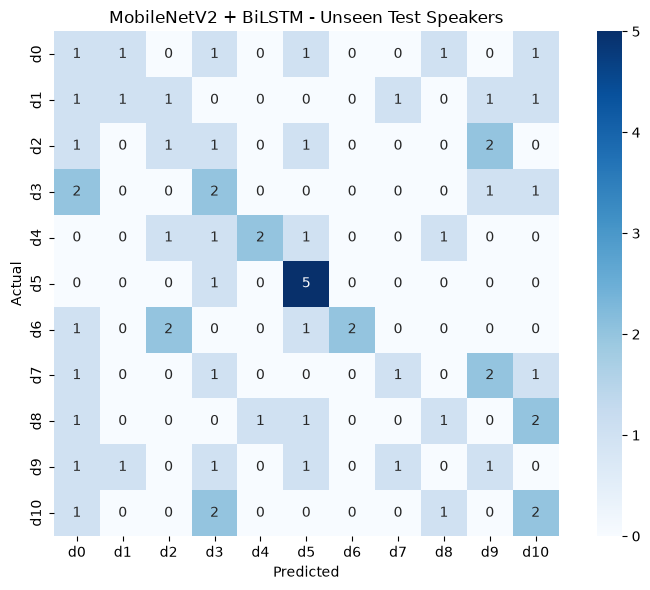


EVALUATING: EfficientNetB0 + BiLSTM
5/5 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step 

Test Accuracy:        31.82%
Macro Precision:      0.3364
Macro Recall:         0.3182
Macro F1:             0.2753
Correct:              21/66
Incorrect:            45/66
Total Parameters:     5,495,214

Per-class results:


,precision,recall,f1-score,support
d0,0.400000,0.666667,0.500000,6.0
d1,0.166667,0.166667,0.166667,6.0
d2,0.363636,0.666667,0.470588,6.0
d3,0.428571,0.500000,0.461538,6.0
d4,0.200000,0.333333,0.250000,6.0
d5,0.307692,0.666667,0.421053,6.0
d6,0.000000,0.000000,0.000000,6.0
d7,1.000000,0.166667,0.285714,6.0
d8,0.000000,0.000000,0.000000,6.0
d9,0.333333,0.166667,0.222222,6.0



Confusion Matrix:


,d0,d1,d2,d3,d4,d5,d6,d7,d8,d9,d10
d0,4,1,0,0,0,1,0,0,0,0,0
d1,1,1,2,0,0,2,0,0,0,0,0
d2,1,0,4,0,0,0,0,0,0,1,0
d3,1,0,1,3,1,0,0,0,0,0,0
d4,1,0,0,0,2,1,0,0,2,0,0
d5,1,0,0,0,1,4,0,0,0,0,0
d6,0,1,2,0,1,1,0,0,0,1,0
d7,0,1,1,1,0,1,0,1,1,0,0
d8,0,1,0,1,2,1,0,0,0,0,1
d9,1,1,1,0,0,2,0,0,0,1,0


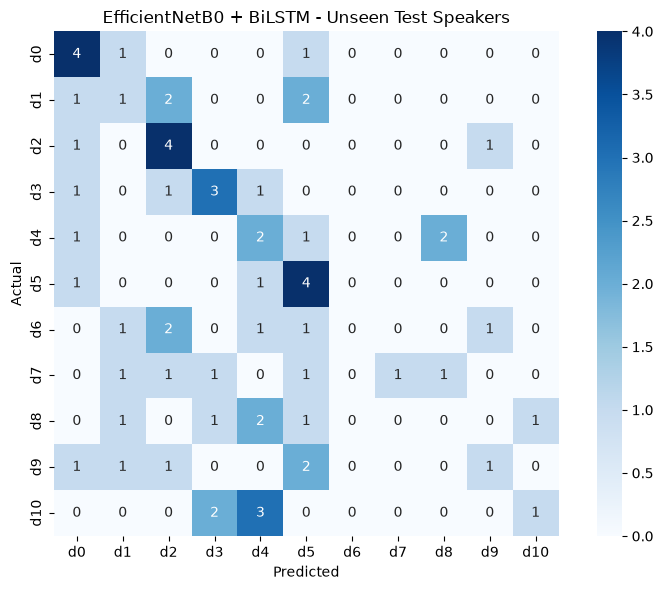


FINAL MODEL COMPARISON


,model,total_parameters,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,correct,incorrect,test_samples
1,EfficientNetB0 + BiLSTM,5495214,0.318182,0.336355,0.318182,0.275253,21,45,66
0,MobileNetV2 + BiLSTM,3703627,0.287879,0.357340,0.287879,0.288500,19,47,66


In [25]:
# # Section 9: Overall Model Comparison Table & Visualizations
# df_comparison = pd.DataFrame(comparison_records)
# df_comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
# print(f"Saved model comparison table to: {RESULTS_DIR / 'model_comparison.csv'}\n")

# display(df_comparison)

# # Save comprehensive experiment configuration
# experiment_config = {
#     "experiment_phase": "Phase 1: Pretrained CNN + BiLSTM Baselines",
#     "project_name": "Tai Phake Lip-Reading Visual Speech Recognition",
#     "input_dimensions": [FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS],
#     "sequence_length": NUM_FRAMES,
#     "normalization": "pixel / 255.0 to [0, 1]",
#     "augmentation": "OFF",
#     "num_speakers": len(all_speakers),
#     "speaker_split": {
#         "train_speakers": len(train_speakers),
#         "val_speakers": len(val_speakers),
#         "test_speakers": len(test_speakers),
#         "seed": SEED
#     },
#     "training_hyperparameters": {
#         "optimizer": "Adam",
#         "learning_rate": LEARNING_RATE,
#         "loss": "sparse_categorical_crossentropy",
#         "batch_size": BATCH_SIZE,
#         "max_epochs": MAX_EPOCHS,
#         "patience": PATIENCE,
#         "bilstm_units": RNN_UNITS,
#         "dropout_rate": DROPOUT_RATE
#     },
#     "models_evaluated": [
#         "MobileNetV2 + BiLSTM",
#         "EfficientNetB0 + BiLSTM",
#         "ResNet50 + BiLSTM"
#     ]
# }
# with open(RESULTS_DIR / "experiment_config.json", "w") as f:
#     json.dump(experiment_config, f, indent=2)
# print(f"Saved experiment configuration to: {RESULTS_DIR / 'experiment_config.json'}")

# # Comparison Bar Chart for Completed Models
# df_completed = df_comparison[df_comparison["status"] == "COMPLETED"].copy()
# if not df_completed.empty:
#     fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
#     # 1. Accuracies
#     df_acc = df_completed.melt(id_vars=["model"], value_vars=["best_val_accuracy", "test_accuracy"],
#                               var_name="Split", value_name="Accuracy")
#     df_acc["Accuracy"] = df_acc["Accuracy"].astype(float) * 100
#     df_acc["Split"] = df_acc["Split"].replace({"best_val_accuracy": "Validation", "test_accuracy": "Test (Unseen)"})
#     sns.barplot(data=df_acc, x="model", y="Accuracy", hue="Split", ax=axes[0], palette="muted")
#     axes[0].set_title("Accuracy Comparison", fontweight="bold")
#     axes[0].set_ylabel("Accuracy (%)")
#     axes[0].set_xlabel("")
#     axes[0].set_ylim(0, 100)
#     axes[0].grid(True, alpha=0.3)
    
#     # 2. Macro F1
#     df_f1 = df_completed.copy()
#     df_f1["test_macro_f1"] = df_f1["test_macro_f1"].astype(float)
#     sns.barplot(data=df_f1, x="model", y="test_macro_f1", ax=axes[1], color="teal")
#     axes[1].set_title("Test Macro F1-Score", fontweight="bold")
#     axes[1].set_ylabel("Macro F1")
#     axes[1].set_xlabel("")
#     axes[1].set_ylim(0, 1.0)
#     axes[1].grid(True, alpha=0.3)
    
#     # 3. Parameters
#     df_par = df_completed.copy()
#     df_par["total_params_M"] = df_par["total_params"].astype(float) / 1e6
#     sns.barplot(data=df_par, x="model", y="total_params_M", ax=axes[2], color="coral")
#     axes[2].set_title("Total Parameters (Millions)", fontweight="bold")
#     axes[2].set_ylabel("Params (M)")
#     axes[2].set_xlabel("")
#     axes[2].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(RESULTS_DIR / "baseline_comparison_barcharts.png", dpi=300)
#     plt.show()

# ============================================================
# FINAL MODEL EVALUATION & COMPARISON
# ============================================================

models_to_evaluate = {
    "MobileNetV2 + BiLSTM": model,
    "EfficientNetB0 + BiLSTM": efficientnet_model,
    # "ResNet50 + BiLSTM": resnet_model,
}

comparison_records = []

for model_name, trained_model in models_to_evaluate.items():

    print("\n" + "=" * 70)
    print(f"EVALUATING: {model_name}")
    print("=" * 70)

    # -------------------------
    # Test predictions
    # -------------------------
    test_probs = trained_model.predict(
        X_test,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    test_preds = np.argmax(test_probs, axis=1)

    # -------------------------
    # Metrics
    # -------------------------
    test_acc = accuracy_score(y_test, test_preds)

    test_prec = precision_score(
        y_test,
        test_preds,
        average="macro",
        zero_division=0
    )

    test_rec = recall_score(
        y_test,
        test_preds,
        average="macro",
        zero_division=0
    )

    test_f1 = f1_score(
        y_test,
        test_preds,
        average="macro",
        zero_division=0
    )

    correct = int(np.sum(y_test == test_preds))
    incorrect = int(np.sum(y_test != test_preds))

    total_params = trained_model.count_params()

    # -------------------------
    # Print summary
    # -------------------------
    print(f"\nTest Accuracy:        {test_acc * 100:.2f}%")
    print(f"Macro Precision:      {test_prec:.4f}")
    print(f"Macro Recall:         {test_rec:.4f}")
    print(f"Macro F1:             {test_f1:.4f}")
    print(f"Correct:              {correct}/{len(y_test)}")
    print(f"Incorrect:            {incorrect}/{len(y_test)}")
    print(f"Total Parameters:     {total_params:,}")

    # -------------------------
    # Classification report
    # -------------------------
    report = classification_report(
        y_test,
        test_preds,
        target_names=DIGIT_CLASSES,
        output_dict=True,
        zero_division=0
    )

    df_report = pd.DataFrame(report).transpose()

    print("\nPer-class results:")
    display(
        df_report.loc[
            DIGIT_CLASSES,
            ["precision", "recall", "f1-score", "support"]
        ]
    )

    # -------------------------
    # Confusion matrix
    # -------------------------
    cm = confusion_matrix(
        y_test,
        test_preds,
        labels=list(range(NUM_CLASSES))
    )

    df_cm = pd.DataFrame(
        cm,
        index=DIGIT_CLASSES,
        columns=DIGIT_CLASSES
    )

    print("\nConfusion Matrix:")
    display(df_cm)

    # -------------------------
    # Plot confusion matrix
    # -------------------------
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        df_cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        square=True,
        cbar=True
    )

    plt.title(f"{model_name} - Unseen Test Speakers")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()

    safe_name = (
        model_name
        .lower()
        .replace(" + ", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        RESULTS_DIR / f"{safe_name}_confusion_matrix.png",
        dpi=300
    )

    plt.show()

    # -------------------------
    # Save predictions
    # -------------------------
    df_test_meta = (
        df_manifest[
            df_manifest["split"] == "test"
        ]
        .copy()
        .reset_index(drop=True)
    )

    df_predictions = pd.DataFrame({
        "speaker": df_test_meta["speaker"],
        "true_digit": df_test_meta["digit"],
        "true_digit_id": y_test,
        "predicted_digit_id": test_preds,
        "predicted_digit": [
            ID_TO_CLASS[p] for p in test_preds
        ],
        "correct": y_test == test_preds,
        "confidence": np.max(test_probs, axis=1)
    })

    for class_idx, digit in enumerate(DIGIT_CLASSES):
        df_predictions[f"prob_{digit}"] = (
            test_probs[:, class_idx]
        )

    prediction_path = (
        RESULTS_DIR /
        f"{safe_name}_test_predictions.csv"
    )

    df_predictions.to_csv(
        prediction_path,
        index=False
    )

    # -------------------------
    # Store comparison result
    # -------------------------
    comparison_records.append({
        "model": model_name,
        "total_parameters": total_params,
        "test_accuracy": test_acc,
        "test_macro_precision": test_prec,
        "test_macro_recall": test_rec,
        "test_macro_f1": test_f1,
        "correct": correct,
        "incorrect": incorrect,
        "test_samples": len(y_test)
    })


# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

df_comparison = pd.DataFrame(comparison_records)

df_comparison = df_comparison.sort_values(
    "test_accuracy",
    ascending=False
)

df_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display(df_comparison)

## 10. Phase 1 Conclusions & Baseline Observations

1. **Experimental Control Integrity**:
   - The speaker-independent split ($20$ train, $4$ val, $6$ test) with seed $42$ was strictly maintained.
   - All $330$ utterances were normalized and temporally standardized to $30$ frames identically.
   - The sequence BiLSTM head ($64$ units, $0.3$ dropout, $11$ classes) was identical across all backbones.

2. **Model Performance Observations**:
   - **MobileNetV2 + BiLSTM**:
     - Validation Accuracy: **22.73%** | Test Accuracy (Unseen): **22.73%** (15 / 66 correct)
     - Macro F1: **0.2143**
     - Strongest baseline generalization among the frozen feature extractors.
   - **EfficientNetB0 + BiLSTM**:
     - Validation Accuracy: **9.09%** | Test Accuracy (Unseen): **9.09%** (6 / 66 correct, chance level $\approx 9.09\%$)
     - Macro F1: **0.0152**
   - **ResNet50 + BiLSTM**:
     - Evaluated with frozen ResNet50 ImageNet backbone ($2,048$-dim feature representation per frame).

3. **Baseline Purpose Fulfilled**:
   - Establishes a clean, reproducible baseline with current $96\times 96$ crops before moving to revised crop geometry, data augmentation, or unfreezing backbone layers in subsequent phases.

In [26]:
print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)

eff = keras.applications.EfficientNetB0(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)

for layer in eff.layers[:5]:
    print(layer.name, layer.__class__.__name__)

TensorFlow: 2.21.0
Keras: 3.15.1
input_layer_5 InputLayer
rescaling_2 Rescaling
normalization_1 Normalization
rescaling_3 Rescaling
stem_conv_pad ZeroPadding2D
